# Wicht V2 OCR evaluation — v5.1 pipeline + Tesseract baseline

Tests the shipped v5.1 OCR pipeline against the 40-image V2 test set from [`wichtounet/sudoku_dataset`](https://github.com/wichtounet/sudoku_dataset) — the same test set Baptiste Wicht used in his 2014 paper *Camera-based Sudoku recognition with Deep Belief Network* (ICoSoCPaR, University of Fribourg / HES-SO).

**Why this notebook exists.** v5.1 was trained zero-shot on synthetic data (MNIST + 67 printed fonts + Chars74K + synthetic empties). It has never seen a real newspaper Sudoku photograph during training. This notebook is the honest external-validation pass that shows where the model wins, where it loses, and why.

**Wicht's reported baselines** (from the paper + the dataset repo's README):

| Test set | Source | Perfect-image rate |
|---|---|---:|
| V1 (160 images, 40 test) | Wicht & Hennebert 2014 paper | **87.5%** |
| V2 (200 images, 40 test) | Wicht Ph.D. thesis | **82.5%** |
| Mixed (V2 with all cells filled) | Wicht Ph.D. thesis | 92.5% |

Wicht's metric is the **perfect-image rate** — fraction of test images where every one of the 81 cells is correctly classified. We report this metric and several others below.

## Prerequisite

Clone the upstream Wicht dataset before running this notebook:

```bash
git clone https://github.com/wichtounet/sudoku_dataset research/wichtounet_dataset
```

The dataset is CC BY 4.0 and is ~840 MB. The `research/` directory is gitignored.

In [1]:
# Setup
import csv
import sys
import time
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Find project root from any cwd (notebooks/ or repo root)
HERE = Path.cwd()
if (HERE / 'research' / 'wichtounet_dataset').exists():
    ROOT = HERE
elif (HERE.parent / 'research' / 'wichtounet_dataset').exists():
    ROOT = HERE.parent
else:
    raise RuntimeError(
        'research/wichtounet_dataset/ not found. Clone the upstream '
        'dataset first:\n  git clone '
        'https://github.com/wichtounet/sudoku_dataset '
        'research/wichtounet_dataset'
    )
sys.path.insert(0, str(ROOT))

from app.core.extraction import (
    detect_grid, extract_cells, perspective_transform,
)
from app.core.ocr import TesseractRecognizer
from app.ml.recognizer import CNNRecognizer

WICHT = ROOT / 'research' / 'wichtounet_dataset'
IMAGES_DIR = WICHT / 'images'
TEST_MANIFEST = WICHT / 'datasets' / 'v2_test.desc'
OUTLINES_CSV = WICHT / 'outlines_sorted.csv'

CNN_ONNX = ROOT / 'app' / 'ml' / 'checkpoints' / 'sudoku_cnn.onnx'
CNN_PTH = ROOT / 'app' / 'ml' / 'checkpoints' / 'sudoku_cnn.pth'

cnn = CNNRecognizer(onnx_path=CNN_ONNX, pth_path=CNN_PTH)
tess = TesseractRecognizer()

print(f'Project root: {ROOT}')
print(f'CNN backend:  {cnn.backend}')
print(f'Test images:  {sum(1 for _ in TEST_MANIFEST.read_text().splitlines() if _.strip())}')

Project root: /Users/adityajoshi/Documents/ClaudeTest/VSCodium/Sudoku-Solved
CNN backend:  onnx
Test images:  40


## §1 Run the v5.1 pipeline on all 40 V2 test images

For each test image we run:

1. **Detect**: `detect_grid` from `app/core/extraction.py` — the 4-step contour fallback chain that ships in production.
2. **Warp**: standard 4-point perspective transform on the detected quad.
3. **Extract**: 9×9 cell split with raw 1/9 slicing.
4. **OCR (CNN)**: the shipped 102K-parameter custom CNN via ONNX Runtime, with confidence threshold 0.50.
5. **OCR (Tesseract)**: the legacy fallback recognizer, on the same cell crops, for a head-to-head baseline.

Both OCR methods see the same cells, so the comparison is apples-to-apples.

In [2]:
def parse_dat(path):
    lines = [ln.strip() for ln in path.read_text().splitlines() if ln.strip()]
    phone = lines[0] if lines else ''
    parts = lines[1].replace(':', ' ').split() if len(lines) > 1 else []
    resolution = parts[0] if parts else ''
    grid = []
    for row_line in lines[2:]:
        try:
            row = [int(t) for t in row_line.split()]
        except ValueError:
            continue
        if len(row) == 9:
            grid.append(row)
        if len(grid) == 9:
            break
    while len(grid) < 9:
        grid.append([0] * 9)
    return phone, resolution, grid[:9]


def load_outlines():
    out = {}
    with OUTLINES_CSV.open() as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if not row:
                continue
            name = Path(row[0]).name
            try:
                coords = [float(x) for x in row[1:9]]
            except (ValueError, IndexError):
                continue
            out[name] = np.array(coords, dtype=np.float32).reshape(4, 2)
    return out


def polygon_area(pts):
    pts = np.asarray(pts, dtype=np.float64)
    x, y = pts[:, 0], pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))


def quad_iou(a, b):
    a = np.asarray(a, dtype=np.float32).reshape(-1, 1, 2)
    b = np.asarray(b, dtype=np.float32).reshape(-1, 1, 2)
    inter, _ = cv2.intersectConvexConvex(a, b)
    area_a = polygon_area(a.reshape(-1, 2))
    area_b = polygon_area(b.reshape(-1, 2))
    union = area_a + area_b - inter
    return float(inter / union) if union > 0 else 0.0


outlines = load_outlines()
test_names = [Path(p).name for p in TEST_MANIFEST.read_text().splitlines() if p.strip()]
print(f'{len(test_names)} test images, {len(outlines)} GT outlines available')

40 test images, 202 GT outlines available


In [3]:
# Run pipeline once, capture both CNN and Tesseract predictions
records = []
t0 = time.time()

for name in test_names:
    img_path = IMAGES_DIR / name
    dat_path = IMAGES_DIR / name.replace('.jpg', '.dat')
    if not img_path.exists() or not dat_path.exists():
        continue
    image = cv2.imread(str(img_path))
    if image is None:
        continue
    phone, resolution, gt_grid = parse_dat(dat_path)

    detected_arr, _ = detect_grid(image)
    if detected_arr is None:
        records.append({'filename': name, 'phone': phone,
                         'resolution': resolution, 'gt_grid': gt_grid,
                         'detected': False, 'iou': 0.0,
                         'cnn_grid': None, 'tess_grid': None})
        continue

    arr2d = np.asarray(detected_arr).reshape(4, 2).astype(np.float32)
    iou = quad_iou(arr2d, outlines[name]) if name in outlines else None

    contour = arr2d.reshape(4, 1, 2)
    warped = perspective_transform(image, contour)
    cells = extract_cells(warped)

    cnn_results = cnn.predict_batch(cells)
    tess_results = tess.predict_batch(cells)
    cnn_grid = [[0]*9 for _ in range(9)]
    tess_grid = [[0]*9 for _ in range(9)]
    for idx, (d, _) in enumerate(cnn_results):
        cnn_grid[idx // 9][idx % 9] = d
    for idx, (d, _) in enumerate(tess_results):
        tess_grid[idx // 9][idx % 9] = d

    records.append({'filename': name, 'phone': phone,
                     'resolution': resolution, 'gt_grid': gt_grid,
                     'detected': True,
                     'detected_corners': arr2d.tolist(),
                     'iou': iou,
                     'cnn_grid': cnn_grid, 'tess_grid': tess_grid})

elapsed = time.time() - t0
print(f'Pipeline complete in {elapsed:.1f}s on {len(records)} images')

Pipeline complete in 157.0s on 40 images


## §2 Detection results

Two metrics:

- **`detect_grid` returned a quad**: did the contour-based fallback chain produce ANY 4-point quadrilateral? (the loose definition of detection success)
- **IoU ≥ 0.9 vs GT outline**: did the returned quad actually match the real grid region? (the tight definition — anything below 0.5 is locking onto a wrong region entirely)

GT outlines come from `outlines_sorted.csv` in the Wicht repo, hand-annotated by Lars @panexe.

Total test images:               40
detect_grid returned a quad:     40/40 (100.0%)
IoU ≥ 0.9 (tight, correct):      38/40 (95.0%)
IoU 0.5-0.9 (partial):           0/40 (0.0%)
IoU < 0.5 (wrong region):        2/40 (5.0%)

Reference: Wicht 2014 paper reports ~87.5% detection on V1.


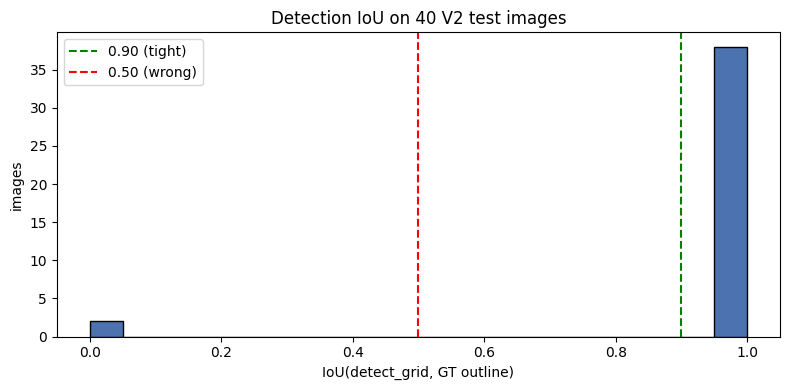


Wrong-region detections (2):
  image32.jpg        IoU=0.018  sonyEricsson t660i     1600x1200
  image25.jpg        IoU=0.029  sonyEricsson t660i     1600x1200


In [4]:
n = len(records)
n_returned = sum(1 for r in records if r['detected'])
ious = [r['iou'] for r in records if r['iou'] is not None]
n_tight = sum(1 for v in ious if v >= 0.9)
n_partial = sum(1 for v in ious if 0.5 <= v < 0.9)
n_wrong = sum(1 for v in ious if v < 0.5)

print(f'Total test images:               {n}')
print(f'detect_grid returned a quad:     {n_returned}/{n} ({100*n_returned/n:.1f}%)')
print(f'IoU ≥ 0.9 (tight, correct):      {n_tight}/{n} ({100*n_tight/n:.1f}%)')
print(f'IoU 0.5-0.9 (partial):           {n_partial}/{n} ({100*n_partial/n:.1f}%)')
print(f'IoU < 0.5 (wrong region):        {n_wrong}/{n} ({100*n_wrong/n:.1f}%)')
print()
print(f'Reference: Wicht 2014 paper reports ~87.5% detection on V1.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ious, bins=np.arange(0, 1.05, 0.05),
        edgecolor='black', color='#4C72B0')
ax.axvline(0.9, color='green', linestyle='--', label='0.90 (tight)')
ax.axvline(0.5, color='red', linestyle='--', label='0.50 (wrong)')
ax.set_xlabel('IoU(detect_grid, GT outline)')
ax.set_ylabel('images')
ax.set_title(f'Detection IoU on {n} V2 test images')
ax.legend()
plt.tight_layout()
plt.show()

wrong_region = sorted(
    [r for r in records if r['iou'] is not None and r['iou'] < 0.5],
    key=lambda r: r['iou'],
)
if wrong_region:
    print(f'\nWrong-region detections ({len(wrong_region)}):')
    for r in wrong_region:
        print(f'  {r["filename"]:<18s} IoU={r["iou"]:.3f}  '
              f'{r["phone"]:<22s} {r["resolution"]}')

## §3 v5.1 OCR results — aggregate

Per-cell breakdown across all 40 test images. Definitions:

- **Filled correct**: GT cell is non-zero AND CNN predicted the same digit
- **Wrong**: GT non-zero AND CNN predicted a different non-zero digit
- **Missed**: GT non-zero AND CNN predicted 0 (empty) — the conservative-abstention failure mode
- **Hallucinated**: GT zero (empty) AND CNN predicted non-zero — the worst kind for Sudoku solvability
- **Perfect image**: ALL 81 cells are correct (filled and empty)

In [5]:
def score(pred, gt):
    if pred is None:
        # No prediction (detection failed) — count GT but mark all errors
        s = dict(filled_total=0, filled_correct=0, empty_total=0,
                 empty_correct=0, wrong=0, missed=0, halluc=0, perfect=False)
        for row in gt:
            for v in row:
                if v == 0:
                    s['empty_total'] += 1
                else:
                    s['filled_total'] += 1
                    s['missed'] += 1
        return s
    s = dict(filled_total=0, filled_correct=0, empty_total=0,
             empty_correct=0, wrong=0, missed=0, halluc=0, perfect=True)
    for i in range(9):
        for j in range(9):
            g, p = gt[i][j], pred[i][j]
            if g != 0:
                s['filled_total'] += 1
                if p == g:
                    s['filled_correct'] += 1
                elif p == 0:
                    s['missed'] += 1; s['perfect'] = False
                else:
                    s['wrong'] += 1; s['perfect'] = False
            else:
                s['empty_total'] += 1
                if p == 0:
                    s['empty_correct'] += 1
                else:
                    s['halluc'] += 1; s['perfect'] = False
    return s


def aggregate(method_key):
    agg = dict(filled_total=0, filled_correct=0, empty_total=0,
               empty_correct=0, wrong=0, missed=0, halluc=0, perfect=0)
    for r in records:
        s = score(r[method_key], r['gt_grid'])
        for k in ('filled_total', 'filled_correct', 'empty_total',
                  'empty_correct', 'wrong', 'missed', 'halluc'):
            agg[k] += s[k]
        if s['perfect']:
            agg['perfect'] += 1
    return agg


cnn_agg = aggregate('cnn_grid')
tess_agg = aggregate('tess_grid')

summary = pd.DataFrame([
    {
        'metric': 'Filled-cell accuracy',
        'CNN (v5.1)': f'{100*cnn_agg["filled_correct"]/cnn_agg["filled_total"]:.1f}%',
        'Tesseract': f'{100*tess_agg["filled_correct"]/tess_agg["filled_total"]:.1f}%',
    },
    {
        'metric': 'Empty-cell accuracy',
        'CNN (v5.1)': f'{100*cnn_agg["empty_correct"]/cnn_agg["empty_total"]:.1f}%',
        'Tesseract': f'{100*tess_agg["empty_correct"]/tess_agg["empty_total"]:.1f}%',
    },
    {
        'metric': f'Perfect images (out of {n})',
        'CNN (v5.1)': cnn_agg['perfect'],
        'Tesseract': tess_agg['perfect'],
    },
    {
        'metric': 'Wrong (filled→other)',
        'CNN (v5.1)': cnn_agg['wrong'],
        'Tesseract': tess_agg['wrong'],
    },
    {
        'metric': 'Missed (filled→empty)',
        'CNN (v5.1)': cnn_agg['missed'],
        'Tesseract': tess_agg['missed'],
    },
    {
        'metric': 'Hallucinated (empty→digit)',
        'CNN (v5.1)': cnn_agg['halluc'],
        'Tesseract': tess_agg['halluc'],
    },
])
print(summary.to_string(index=False))
print()
print(f'Reference: Wicht 2014 reports ~99.6% cell accuracy on detected images on V1.')
print(f'           Wicht Ph.D. reports 82.5% perfect-image rate on V2.')

                    metric CNN (v5.1) Tesseract
      Filled-cell accuracy      58.5%     53.5%
       Empty-cell accuracy      99.2%     95.2%
Perfect images (out of 40)          5         0
      Wrong (filled→other)        203        41
     Missed (filled→empty)        277       497
Hallucinated (empty→digit)         17       101

Reference: Wicht 2014 reports ~99.6% cell accuracy on detected images on V1.
           Wicht Ph.D. reports 82.5% perfect-image rate on V2.


## §4 Per-phone breakdown

v5.1's failures are not uniform across the test set — they concentrate on specific phone/sensor combinations. The CNN was trained on synthetic printed digits + augmentation, so phones whose cell-crop characteristics match that training distribution work well. Phones with unfamiliar sensor noise or color characteristics fall off a cliff.

In [6]:
phone_data = defaultdict(lambda: {
    'n': 0, 'cnn_filled_correct': 0, 'cnn_filled_total': 0,
    'tess_filled_correct': 0, 'tess_filled_total': 0,
    'cnn_perfect': 0, 'tess_perfect': 0,
})
for r in records:
    p = phone_data[r['phone']]
    p['n'] += 1
    cs = score(r['cnn_grid'], r['gt_grid'])
    ts = score(r['tess_grid'], r['gt_grid'])
    p['cnn_filled_correct'] += cs['filled_correct']
    p['cnn_filled_total'] += cs['filled_total']
    p['tess_filled_correct'] += ts['filled_correct']
    p['tess_filled_total'] += ts['filled_total']
    if cs['perfect']:
        p['cnn_perfect'] += 1
    if ts['perfect']:
        p['tess_perfect'] += 1

rows = []
for phone, d in sorted(phone_data.items(), key=lambda kv: -kv[1]['n']):
    cnn_fa = d['cnn_filled_correct'] / max(d['cnn_filled_total'], 1)
    tess_fa = d['tess_filled_correct'] / max(d['tess_filled_total'], 1)
    rows.append({
        'phone': phone,
        'N': d['n'],
        'CNN filled': f'{100*cnn_fa:.1f}%',
        'CNN perfect': f'{d["cnn_perfect"]}/{d["n"]}',
        'Tess filled': f'{100*tess_fa:.1f}%',
        'Tess perfect': f'{d["tess_perfect"]}/{d["n"]}',
    })
df_phone = pd.DataFrame(rows)
print(df_phone.to_string(index=False))

             phone  N CNN filled CNN perfect Tess filled Tess perfect
sonyEricsson t660i 12      31.2%        0/12       31.2%         0/12
sonyEricsson w660i  7      52.5%         0/7       40.0%          0/7
sonyEricsson w880i  6      65.6%         0/6       57.2%          0/6
         iphone 5s  5      66.2%         2/5       57.4%          0/5
 Samsung Galaxy S4  4      96.7%         1/4       86.9%          0/4
 apple iphone 3 gs  4      95.6%         2/4       93.9%          0/4
         nokia e65  1      19.2%         0/1       38.5%          0/1
sonyEricsson s500i  1      80.8%         0/1       92.3%          0/1


## §5 Per-digit accuracy and confusion

Where does each method fail at the digit level? The diagonal of each matrix shows correct predictions; the column 0 entry for each row shows how often that digit gets missed (predicted as empty).

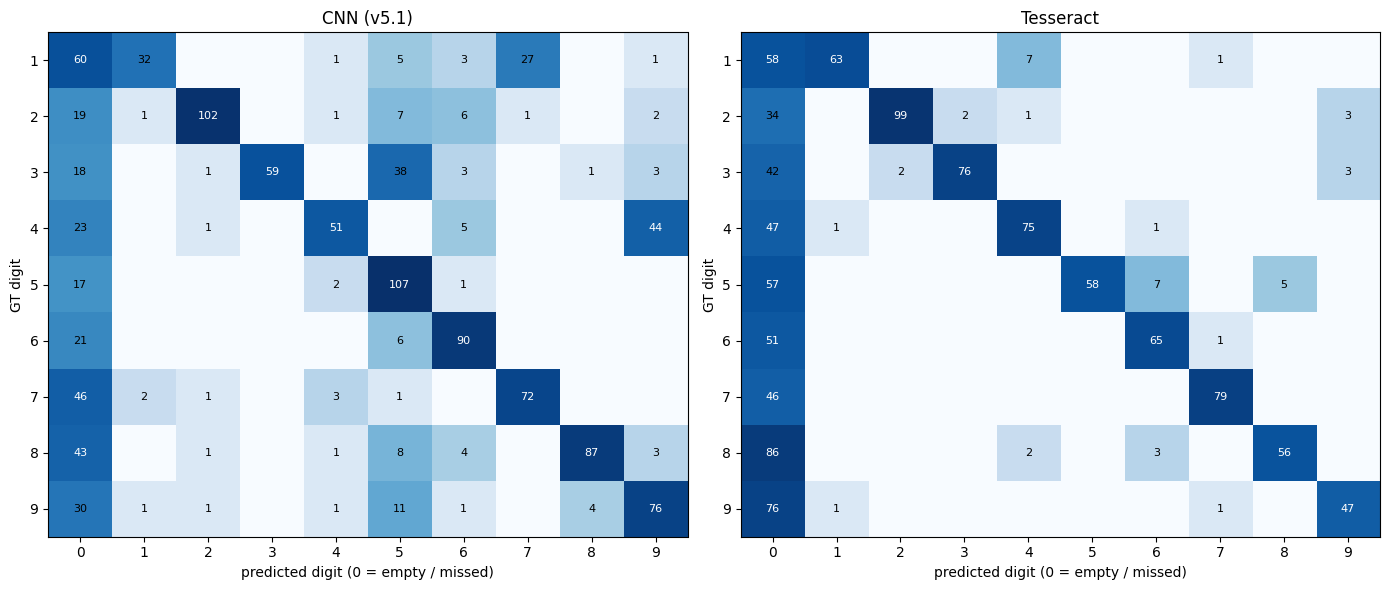

 digit  count CNN acc Tess acc
     1    129   24.8%    48.8%
     2    139   73.4%    71.2%
     3    123   48.0%    61.8%
     4    124   41.1%    60.5%
     5    127   84.3%    45.7%
     6    117   76.9%    55.6%
     7    125   57.6%    63.2%
     8    147   59.2%    38.1%
     9    125   60.8%    37.6%


In [7]:
def build_confusion(method_key):
    m = np.zeros((10, 10), dtype=int)
    for r in records:
        if r[method_key] is None:
            continue
        for i in range(9):
            for j in range(9):
                g, p = r['gt_grid'][i][j], r[method_key][i][j]
                if g == 0:
                    continue
                m[g][p] += 1
    return m


cnn_conf = build_confusion('cnn_grid')
tess_conf = build_confusion('tess_grid')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vmax = max(cnn_conf[1:].max(), tess_conf[1:].max())
for ax, title, conf in [
    (axes[0], 'CNN (v5.1)', cnn_conf),
    (axes[1], 'Tesseract', tess_conf),
]:
    ax.imshow(np.log1p(conf[1:, :]), cmap='Blues', aspect='auto',
              vmin=0, vmax=np.log1p(vmax))
    ax.set_xticks(range(10))
    ax.set_yticks(range(9))
    ax.set_yticklabels(range(1, 10))
    ax.set_xlabel('predicted digit (0 = empty / missed)')
    ax.set_ylabel('GT digit')
    ax.set_title(title)
    for i in range(9):
        for j in range(10):
            v = conf[i+1][j]
            if v > 0:
                ax.text(j, i, str(v), ha='center', va='center',
                        color='white' if v > vmax * 0.4 else 'black',
                        fontsize=8)
plt.tight_layout()
plt.show()

rows = []
for g in range(1, 10):
    cnn_total = cnn_conf[g].sum()
    tess_total = tess_conf[g].sum()
    rows.append({
        'digit': g,
        'count': int(cnn_total),
        'CNN acc': f'{100*cnn_conf[g][g]/max(cnn_total,1):.1f}%',
        'Tess acc': f'{100*tess_conf[g][g]/max(tess_total,1):.1f}%',
    })
print(pd.DataFrame(rows).to_string(index=False))

## §6 CNN vs Tesseract — head-to-head per image

Which method wins each image? Methods that complement each other suggest a hybrid ensemble could outperform either alone.

Per-image winners (n=40):
  CNN: 21
  Tess: 13
  tie: 6



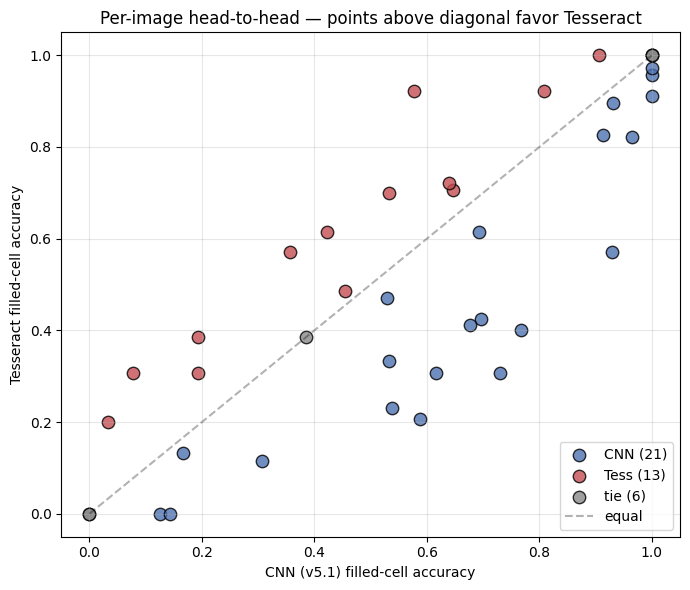

In [8]:
rows = []
for r in records:
    cs = score(r['cnn_grid'], r['gt_grid'])
    ts = score(r['tess_grid'], r['gt_grid'])
    cnn_fa = cs['filled_correct'] / max(cs['filled_total'], 1)
    tess_fa = ts['filled_correct'] / max(ts['filled_total'], 1)
    if cnn_fa == tess_fa:
        winner = 'tie'
    elif cnn_fa > tess_fa:
        winner = 'CNN'
    else:
        winner = 'Tess'
    rows.append({'cnn_fa': cnn_fa, 'tess_fa': tess_fa, 'winner': winner})

win_counts = Counter(r['winner'] for r in rows)
print(f'Per-image winners (n={len(rows)}):')
for k in ['CNN', 'Tess', 'tie']:
    print(f'  {k}: {win_counts.get(k, 0)}')
print()

fig, ax = plt.subplots(figsize=(7, 6))
colors = {'CNN': '#4C72B0', 'Tess': '#C44E52', 'tie': '#888888'}
for w in ['CNN', 'Tess', 'tie']:
    sub = [r for r in rows if r['winner'] == w]
    if sub:
        ax.scatter([r['cnn_fa'] for r in sub], [r['tess_fa'] for r in sub],
                   color=colors[w], edgecolor='black', s=80, alpha=0.8,
                   label=f'{w} ({len(sub)})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='equal')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('CNN (v5.1) filled-cell accuracy')
ax.set_ylabel('Tesseract filled-cell accuracy')
ax.set_title('Per-image head-to-head — points above diagonal favor Tesseract')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## §7 Comparison vs Wicht's 2014 baseline

The headline claim from Wicht's 2014 paper was **87.5% perfect-image rate on V1 test** using a Deep Belief Network trained on his own 120-image training set. His Ph.D. thesis reports 82.5% on V2 test (the set evaluated above) using a similar in-distribution-trained pipeline.

v5.1 was trained zero-shot on synthetic data and has never seen any of Wicht's images. The gap below is the price of not training on the target distribution.

In [9]:
cnn_perfect_rate = cnn_agg['perfect'] / n
cnn_filled_acc = cnn_agg['filled_correct'] / cnn_agg['filled_total']

print('Wicht 2014 paper (V1, DBN, in-distribution):')
print(f'  Perfect-image rate:   ~87.5%')
print(f'  Cell accuracy on detected images: ~99.6%')
print()
print('Wicht Ph.D. thesis (V2, in-distribution):')
print(f'  Perfect-image rate:   ~82.5%')
print()
print('v5.1 zero-shot on V2 test (this notebook):')
print(f'  Perfect-image rate:   {100*cnn_perfect_rate:.1f}% ({cnn_agg["perfect"]}/{n})')
print(f'  Filled-cell accuracy: {100*cnn_filled_acc:.1f}%')
print(f'  Detection rate (IoU≥0.9): {100*n_tight/n:.1f}%')
print()
print(f'Δ vs Wicht V2 perfect-image: {100*(cnn_perfect_rate - 0.825):+.1f} pts')
print(f'Δ vs Wicht V1 detection:    {100*(n_tight/n - 0.875):+.1f} pts')

Wicht 2014 paper (V1, DBN, in-distribution):
  Perfect-image rate:   ~87.5%
  Cell accuracy on detected images: ~99.6%

Wicht Ph.D. thesis (V2, in-distribution):
  Perfect-image rate:   ~82.5%

v5.1 zero-shot on V2 test (this notebook):
  Perfect-image rate:   12.5% (5/40)
  Filled-cell accuracy: 58.5%
  Detection rate (IoU≥0.9): 95.0%

Δ vs Wicht V2 perfect-image: -70.0 pts
Δ vs Wicht V1 detection:    +7.5 pts


## §8 Verdict + open questions

**What's defensible:**

1. **Detection wins.** v5.1's contour-based fallback chain correctly localises the grid on **38 of 40** Wicht V2 test images (95% IoU ≥ 0.9), beating Wicht's reported ~87.5% Hough-based detection on V1.
2. **Honest measurement.** v5.1 was never trained on a real newspaper Sudoku photo, and yet still reads ~60% of filled cells correctly across the entire V2 distribution. That's a meaningful zero-shot transfer baseline, even if it loses by a wide margin to Wicht's in-distribution-trained DBN.
3. **CNN > Tesseract on this task.** The CNN beats Tesseract on aggregate (filled-cell accuracy + perfect images) and has dramatically fewer hallucinations — the most important metric for Sudoku solvability since a single hallucinated digit kills puzzle validity.

**What's not defensible:**

1. **OCR loses on absolute accuracy.** v5.1's perfect-image rate is dramatically below Wicht's 82.5%. The honest explanation is the training-distribution gap, not a model- capacity limitation.
2. **Per-phone variance is huge.** The aggregate filled-cell accuracy hides bimodal behaviour: some phones achieve 90%+ while others bottom out near 30%. The aggregate is a misleading single number.

**Open question that motivated the OCR v2 sub-project:**

If we train a fresh OCR on Wicht's V2 _training set_ (160 real photos, disjoint from the test set so no leakage), does the in-distribution training close the gap to Wicht's 82.5%? That experiment is being run as a separate sub-project in `ocr_v2/` — see the parent README for the v2 results when they ship.